# 04b — Robust Meteorological Driver Analysis **FAST**

This is a computationally optimized replacement for the original `04b_ROBUST_DRIVER_ANALYSIS.ipynb`.

## Why the old version was slow

The original implementation looped over **year × lag**, and inside each combination it called Dask `.compute()` repeatedly for the denominator, event count, and each meteorological variable. That caused large NetCDF chunks to be read/recomputed many times.

## FAST strategy

For each analysis year:

1. read the 73-pentad detection block **once**;
2. read the meteorological block for that year plus ±6 pentads **once**;
3. identify only the grid-cell/time positions actually belonging to benchmark FD starts/phases;
4. calculate all 13 lags in NumPy using sparse indexing;
5. calculate rapid-development and drought-core diagnostics from the same in-memory block;
6. write checkpoint CSV files after every completed year.

The scientific definition and year-blocked inference are unchanged. Only the computational strategy is changed.

**Recommended:** interrupt the old notebook, restart the kernel to release its Dask tasks/memory, then run this notebook from the top.


In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

DETECTION_FILE = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
)
ANOMALY_FILE = Path(
    r"D:\ERA5_LAND\output_fd_04_drivers\meteorological_anomaly_cube_timeindex_1995_2025.nc"
)
CLIMATOLOGY_FILE = Path(
    r"D:\ERA5_LAND\output_fd_04_drivers\meteorological_pentad_climatology_1995_2025.nc"
)

# Separate directory so partial outputs from the old slow run cannot be mixed in.
OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_04b_robust_drivers_fast"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = 1996
END_YEAR = 2024
YEARS = np.arange(START_YEAR, END_YEAR + 1, dtype=int)

LAGS = np.arange(-6, 7, dtype=int)
PRECONDITION_LAGS = [-3, -2, -1]

BOOTSTRAP_REPS = 5000
RANDOM_SEED = 42
FIG_DPI = 250

VARS = ["tp_anom_mm", "t2m_anom_c", "d2m_anom_c", "vpd_anom_kpa"]

# Optional quick test:
# RUN_YEARS = np.array([1996], dtype=int)
RUN_YEARS = YEARS.copy()

print("Output:", OUTPUT_DIR)
print("Years :", RUN_YEARS[0], "-", RUN_YEARS[-1], f"({len(RUN_YEARS)} years)")
print("Lags  :", LAGS[0], "to", LAGS[-1], "pentads")


Output: D:\ERA5_LAND\output_fd_04b_robust_drivers_fast
Years : 1996 - 2024 (29 years)
Lags  : -6 to 6 pentads


In [2]:
# Open lazily. We explicitly .load() only compact year blocks later.
fd = xr.open_dataset(DETECTION_FILE, mask_and_scale=False)
anom = xr.open_dataset(ANOMALY_FILE)
clim = xr.open_dataset(CLIMATOLOGY_FILE)

required_fd = {
    "fd_event_start", "fd_phase", "fd_drought_core", "valid_grid_mask"
}
required_anom = set(VARS)
required_clim = {"tp_mm_std", "t2m_c_std", "vpd_kpa_std"}

missing_fd = required_fd - set(fd.data_vars)
missing_anom = required_anom - set(anom.data_vars)
missing_clim = required_clim - set(clim.data_vars)

if missing_fd:
    raise KeyError(f"Missing detection variables: {sorted(missing_fd)}")
if missing_anom:
    raise KeyError(f"Missing anomaly variables: {sorted(missing_anom)}")
if missing_clim:
    raise KeyError(f"Missing climatology variables: {sorted(missing_clim)}")

if fd.sizes["time_index"] != anom.sizes["time_index"]:
    raise ValueError("Detection and meteorological anomaly time dimensions differ.")

if not np.allclose(fd["latitude"].values, anom["latitude"].values):
    raise ValueError("Latitude grids differ.")
if not np.allclose(fd["longitude"].values, anom["longitude"].values):
    raise ValueError("Longitude grids differ.")

year_values = np.asarray(fd["year"].values, dtype=int)
pentad_values = np.asarray(fd["pentad"].values, dtype=int)

if year_values.size != fd.sizes["time_index"]:
    raise ValueError("year coordinate is not aligned with time_index.")
if pentad_values.size != fd.sizes["time_index"]:
    raise ValueError("pentad coordinate is not aligned with time_index.")

valid_np = np.asarray(fd["valid_grid_mask"].values == 1, dtype=bool)

lat = np.asarray(fd["latitude"].values, dtype=float)
coslat = np.cos(np.deg2rad(lat)).astype(np.float32)

# Area weight is zero outside the valid Indonesian analysis mask.
weight_np = np.where(
    valid_np,
    coslat[:, None],
    0.0
).astype(np.float32)

# Load only 3 climatological SD arrays (~73 pentads), once.
clim_pentads = np.asarray(clim["pentad"].values, dtype=int)
pentad_to_pos = {int(p): i for i, p in enumerate(clim_pentads)}

std_tp_np = np.asarray(clim["tp_mm_std"].load().values, dtype=np.float32)
std_t_np = np.asarray(clim["t2m_c_std"].load().values, dtype=np.float32)
std_vpd_np = np.asarray(clim["vpd_kpa_std"].load().values, dtype=np.float32)

for yr in RUN_YEARS:
    idx = np.flatnonzero(year_values == int(yr))
    if idx.size != 73:
        raise ValueError(
            f"Year {yr} contains {idx.size} pentads; expected 73."
        )
    if not np.array_equal(idx, np.arange(idx[0], idx[-1] + 1)):
        raise ValueError(f"time_index for {yr} is not contiguous.")

print("Grid:", fd.sizes["latitude"], "x", fd.sizes["longitude"])
print("Valid grid cells:", int(valid_np.sum()))
print("Calendar/pentad checks passed.")


Grid: 171 x 461
Valid grid cells: 14857
Calendar/pentad checks passed.


## 1. Single-pass yearly engine

This replaces the expensive `29 years × 13 lags × repeated .compute()` pattern.

The anomaly block loaded for each year contains only `73 + 12 = 85` pentads (year plus ±6 lag padding). All lag composites are then evaluated from that block in memory.

Area weighting uses cosine latitude. Missing meteorological values are excluded from the corresponding weighted denominator.


In [3]:
def safe_weighted_mean(values, weights):
    values = np.asarray(values, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)

    ok = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(ok):
        return np.nan

    w = weights[ok]
    return float(np.sum(values[ok] * w) / np.sum(w))


def safe_weighted_fraction(condition, valid_values, weights):
    condition = np.asarray(condition, dtype=bool)
    valid_values = np.asarray(valid_values, dtype=bool)
    weights = np.asarray(weights, dtype=np.float64)

    ok = valid_values & np.isfinite(weights) & (weights > 0)
    if not np.any(ok):
        return np.nan

    den = np.sum(weights[ok])
    num = np.sum(weights[ok & condition])
    return float(num / den)


def standardize(values, std_values):
    values = np.asarray(values, dtype=np.float64)
    std_values = np.asarray(std_values, dtype=np.float64)

    out = np.full(values.shape, np.nan, dtype=np.float64)
    ok = (
        np.isfinite(values)
        & np.isfinite(std_values)
        & (std_values > 0)
    )
    out[ok] = values[ok] / std_values[ok]
    return out


annual_lag_rows = []
phase_rows = []
core_rows = []

lag_min = int(LAGS.min())
lag_max = int(LAGS.max())
n_time = anom.sizes["time_index"]

run_start = time.perf_counter()

for iyear, yr in enumerate(RUN_YEARS, start=1):
    year_t0 = time.perf_counter()

    year_idx = np.flatnonzero(year_values == int(yr))
    t0 = int(year_idx[0])
    t1 = int(year_idx[-1]) + 1

    # Include lag padding around the year.
    met_lo = t0 + lag_min
    met_hi = t1 + lag_max

    if met_lo < 0 or met_hi > n_time:
        raise IndexError(
            f"Insufficient lag padding for year {yr}: "
            f"requested [{met_lo}:{met_hi}] from {n_time} time steps."
        )

    # ---- Load detection fields ONCE for this year ----
    fd_year = fd[
        ["fd_event_start", "fd_phase", "fd_drought_core"]
    ].isel(time_index=slice(t0, t1)).load()

    start_np = (
        np.asarray(fd_year["fd_event_start"].values == 1, dtype=bool)
        & valid_np[None, :, :]
    )
    rapid_np = (
        np.asarray(fd_year["fd_phase"].values == 1, dtype=bool)
        & valid_np[None, :, :]
    )
    core_np = (
        np.asarray(fd_year["fd_drought_core"].values == 1, dtype=bool)
        & valid_np[None, :, :]
    )

    # ---- Load all four meteorological variables ONCE for this year ± lag ----
    met_block = anom[VARS].isel(
        time_index=slice(met_lo, met_hi)
    ).load()

    met_np = {
        var: np.asarray(met_block[var].values, dtype=np.float32)
        for var in VARS
    }

    # Position of each in-year pentad inside the 85-pentad met block.
    base_pos = np.arange(t0, t1, dtype=int) - met_lo

    # ==========================================================
    # A. Onset-aligned lag composite: sparse event-start sampling
    # ==========================================================
    et, ey, ex = np.nonzero(start_np)
    event_count = int(et.size)

    if event_count > 0:
        ew = weight_np[ey, ex].astype(np.float64)

        for lag in LAGS:
            pos = base_pos[et] + int(lag)

            row = {
                "year": int(yr),
                "lag": int(lag),
                "gridcell_start_count": event_count,
            }

            for var in VARS:
                vals = met_np[var][pos, ey, ex]
                row[var] = safe_weighted_mean(vals, ew)

            annual_lag_rows.append(row)

    # ==========================================================
    # B. Rapid-development standardized driver diagnostics
    # ==========================================================
    rt, ry, rx = np.nonzero(rapid_np)

    if rt.size > 0:
        rw = weight_np[ry, rx].astype(np.float64)
        rpos = base_pos[rt]

        tp_vals = met_np["tp_anom_mm"][rpos, ry, rx]
        t_vals = met_np["t2m_anom_c"][rpos, ry, rx]
        vpd_vals = met_np["vpd_anom_kpa"][rpos, ry, rx]

        year_pentads = pentad_values[t0:t1]
        try:
            clim_pos_by_time = np.array(
                [pentad_to_pos[int(p)] for p in year_pentads],
                dtype=int
            )
        except KeyError as exc:
            raise KeyError(
                f"Pentad {exc.args[0]} is missing from climatology."
            ) from exc

        cp = clim_pos_by_time[rt]

        tp_std_vals = std_tp_np[cp, ry, rx]
        t_std_vals = std_t_np[cp, ry, rx]
        vpd_std_vals = std_vpd_np[cp, ry, rx]

        z_tp = standardize(tp_vals, tp_std_vals)
        z_t = standardize(t_vals, t_std_vals)
        z_vpd = standardize(vpd_vals, vpd_std_vals)

        valid_p = np.isfinite(z_tp)
        valid_t = np.isfinite(z_t)
        valid_v = np.isfinite(z_vpd)
        valid_pv = valid_p & valid_v

        p_def = z_tp <= -1.0
        warm = z_t >= 1.0
        high_vpd = z_vpd >= 1.0

        phase_rows.append({
            "year": int(yr),
            "rapid_gridcell_pentads": int(rt.size),
            "mean_z_precip": safe_weighted_mean(z_tp, rw),
            "mean_z_t2m": safe_weighted_mean(z_t, rw),
            "mean_z_vpd": safe_weighted_mean(z_vpd, rw),
            "strong_precip_deficit_fraction": safe_weighted_fraction(
                p_def, valid_p, rw
            ),
            "warm_fraction": safe_weighted_fraction(
                warm, valid_t, rw
            ),
            "high_vpd_fraction": safe_weighted_fraction(
                high_vpd, valid_v, rw
            ),
            "compound_pdef_highvpd_fraction": safe_weighted_fraction(
                p_def & high_vpd, valid_pv, rw
            ),
            "either_pdef_or_highvpd_fraction": safe_weighted_fraction(
                p_def | high_vpd, valid_pv, rw
            ),
        })

    # ==========================================================
    # C. Drought-core meteorology: sparse phase sampling
    # ==========================================================
    ct, cy, cx = np.nonzero(core_np)

    if ct.size > 0:
        cw = weight_np[cy, cx].astype(np.float64)
        cpos = base_pos[ct]

        core_row = {
            "year": int(yr),
            "core_gridcell_pentads": int(ct.size),
        }

        for var in VARS:
            vals = met_np[var][cpos, cy, cx]
            core_row[var] = safe_weighted_mean(vals, cw)

        core_rows.append(core_row)

    # ---- Checkpoint after every completed year ----
    pd.DataFrame(annual_lag_rows).to_csv(
        OUTPUT_DIR / "_checkpoint_year_block_onset_aligned.csv",
        index=False
    )
    pd.DataFrame(phase_rows).to_csv(
        OUTPUT_DIR / "_checkpoint_rapid_driver_states.csv",
        index=False
    )
    pd.DataFrame(core_rows).to_csv(
        OUTPUT_DIR / "_checkpoint_drought_core.csv",
        index=False
    )

    elapsed = time.perf_counter() - run_start
    year_elapsed = time.perf_counter() - year_t0
    avg = elapsed / iyear
    eta = avg * (len(RUN_YEARS) - iyear)

    print(
        f"{yr}: starts={event_count:,} | "
        f"rapid points={rt.size:,} | core points={ct.size:,} | "
        f"year={year_elapsed:.1f}s | ETA≈{eta/60:.1f} min"
    )

annual_lag = pd.DataFrame(annual_lag_rows)
phase_year = pd.DataFrame(phase_rows)
core_year = pd.DataFrame(core_rows)

annual_lag.to_csv(
    OUTPUT_DIR / "year_block_onset_aligned_composite.csv",
    index=False
)
phase_year.to_csv(
    OUTPUT_DIR / "rapid_development_driver_states_by_year.csv",
    index=False
)
core_year.to_csv(
    OUTPUT_DIR / "drought_core_meteorology_by_year.csv",
    index=False
)

print()
print("Single-pass yearly engine complete.")
print("Elapsed minutes:", round((time.perf_counter() - run_start) / 60, 2))
display(annual_lag.head())


1996: starts=27,672 | rapid points=71,929 | core points=102,382 | year=2.4s | ETA≈1.1 min
1997: starts=25,820 | rapid points=71,997 | core points=374,504 | year=2.1s | ETA≈1.0 min
1998: starts=11,817 | rapid points=32,479 | core points=99,240 | year=2.0s | ETA≈0.9 min
1999: starts=15,656 | rapid points=41,011 | core points=61,959 | year=2.0s | ETA≈0.9 min
2000: starts=19,363 | rapid points=51,219 | core points=83,895 | year=2.0s | ETA≈0.8 min
2001: starts=23,202 | rapid points=64,930 | core points=99,289 | year=1.9s | ETA≈0.8 min
2002: starts=30,320 | rapid points=84,112 | core points=246,432 | year=3.9s | ETA≈0.9 min
2003: starts=26,570 | rapid points=72,298 | core points=174,878 | year=1.9s | ETA≈0.8 min
2004: starts=33,208 | rapid points=91,285 | core points=190,246 | year=1.9s | ETA≈0.7 min
2005: starts=17,450 | rapid points=46,697 | core points=108,688 | year=1.9s | ETA≈0.7 min
2006: starts=21,710 | rapid points=59,700 | core points=126,427 | year=1.9s | ETA≈0.7 min
2007: starts=1

,year,lag,gridcell_start_count,tp_anom_mm,t2m_anom_c,d2m_anom_c,vpd_anom_kpa
0,1996,-6,27672,-3.373076,-0.273843,-0.248832,-0.009144
1,1996,-5,27672,-0.823221,-0.370360,-0.204166,-0.034906
2,1996,-4,27672,4.869575,-0.446682,-0.144052,-0.058900
3,1996,-3,27672,8.143346,-0.508902,-0.163144,-0.068407
4,1996,-2,27672,9.181308,-0.464297,-0.133062,-0.064656


## 2. Year-block bootstrap for onset-aligned composite

The bootstrap is now cheap because it operates only on the small annual summary table created above.


In [4]:
rng = np.random.default_rng(RANDOM_SEED)

def bootstrap_mean_ci(values, nrep=BOOTSTRAP_REPS):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.nan, np.nan, np.nan, 0

    idx = rng.integers(0, x.size, size=(nrep, x.size))
    boot = x[idx].mean(axis=1)

    return (
        float(x.mean()),
        float(np.quantile(boot, 0.025)),
        float(np.quantile(boot, 0.975)),
        int(x.size),
    )


rows = []

for lag in LAGS:
    sub = annual_lag[annual_lag["lag"] == int(lag)]

    for var in VARS:
        mean, lo, hi, n = bootstrap_mean_ci(sub[var])

        rows.append({
            "lag": int(lag),
            "variable": var,
            "mean": mean,
            "ci95_low": lo,
            "ci95_high": hi,
            "n_year_blocks": n,
        })

lag_summary = pd.DataFrame(rows)

lag_summary.to_csv(
    OUTPUT_DIR / "year_block_onset_aligned_composite_bootstrap95.csv",
    index=False
)

display(lag_summary)


,lag,variable,mean,ci95_low,ci95_high,n_year_blocks
0,-6,tp_anom_mm,-2.773034,-4.572504,-1.083165,29
1,-6,t2m_anom_c,-0.028744,-0.106493,0.055177,29
2,-6,d2m_anom_c,-0.044563,-0.121950,0.038492,29
3,-6,vpd_anom_kpa,0.001898,-0.006043,0.009671,29
4,-5,tp_anom_mm,-1.878009,-3.592122,-0.190073,29
5,-5,t2m_anom_c,-0.050757,-0.129791,0.035308,29
6,-5,d2m_anom_c,-0.041218,-0.117000,0.040842,29
7,-5,vpd_anom_kpa,-0.002885,-0.011172,0.005820,29
8,-4,tp_anom_mm,1.374036,-0.390059,3.124039,29
9,-4,t2m_anom_c,-0.079004,-0.166946,0.009635,29


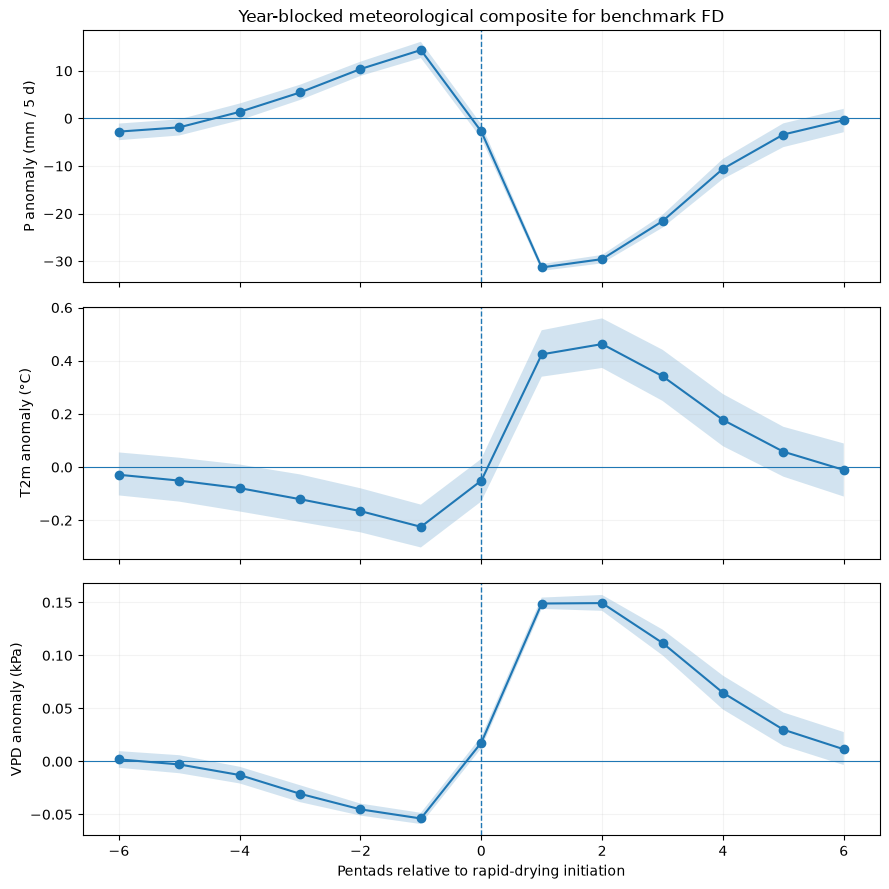

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, var, ylabel in [
    (axes[0], "tp_anom_mm", "P anomaly (mm / 5 d)"),
    (axes[1], "t2m_anom_c", "T2m anomaly (°C)"),
    (axes[2], "vpd_anom_kpa", "VPD anomaly (kPa)"),
]:
    s = lag_summary[
        lag_summary["variable"] == var
    ].sort_values("lag")

    ax.plot(s["lag"], s["mean"], marker="o")
    ax.fill_between(
        s["lag"], s["ci95_low"], s["ci95_high"], alpha=0.2
    )
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linestyle="--", linewidth=1.0)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.15)

axes[-1].set_xlabel(
    "Pentads relative to rapid-drying initiation"
)
axes[0].set_title(
    "Year-blocked meteorological composite for benchmark FD"
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "01_year_block_driver_composite.png",
    dpi=FIG_DPI
)
plt.show()


## 3. Preconditioning fingerprint

Only lags **−3, −2, −1** are treated as preconditioning. Lag 0 is the rapid-drying initiation baseline and is excluded from this preconditioning average.


In [6]:
pre = annual_lag[
    annual_lag["lag"].isin(PRECONDITION_LAGS)
].copy()

pre_year = (
    pre.groupby("year", as_index=False)
    .agg(
        tp_anom_mm=("tp_anom_mm", "mean"),
        t2m_anom_c=("t2m_anom_c", "mean"),
        vpd_anom_kpa=("vpd_anom_kpa", "mean"),
    )
)

pre_summary = pd.DataFrame([{
    "n_years": len(pre_year),
    "mean_tp_anom_mm": pre_year["tp_anom_mm"].mean(),
    "dry_precip_year_fraction": np.mean(
        pre_year["tp_anom_mm"] < 0
    ),
    "mean_t2m_anom_c": pre_year["t2m_anom_c"].mean(),
    "warm_year_fraction": np.mean(
        pre_year["t2m_anom_c"] > 0
    ),
    "mean_vpd_anom_kpa": pre_year["vpd_anom_kpa"].mean(),
    "high_vpd_year_fraction": np.mean(
        pre_year["vpd_anom_kpa"] > 0
    ),
}])

pre_year.to_csv(
    OUTPUT_DIR / "preconditioning_by_year.csv",
    index=False
)
pre_summary.to_csv(
    OUTPUT_DIR / "preconditioning_summary.csv",
    index=False
)

display(pre_summary)


,n_years,mean_tp_anom_mm,dry_precip_year_fraction,mean_t2m_anom_c,warm_year_fraction,mean_vpd_anom_kpa,high_vpd_year_fraction
0,29,10.063351,0.0,-0.170248,0.206897,-0.043236,0.0


## 4. Rapid-development driver states

Diagnostic thresholds:
- strong precipitation deficit: standardized P anomaly ≤ −1;
- anomalous warmth: standardized T2m anomaly ≥ +1;
- high atmospheric aridity: standardized VPD anomaly ≥ +1;
- compound P–VPD state: P ≤ −1 and VPD ≥ +1.

These characterize the meteorological state **during detected rapid development**; they are not part of the flash-drought detection rule.


In [7]:
phase_summary_rows = []

phase_metrics = [
    "mean_z_precip",
    "mean_z_t2m",
    "mean_z_vpd",
    "strong_precip_deficit_fraction",
    "warm_fraction",
    "high_vpd_fraction",
    "compound_pdef_highvpd_fraction",
    "either_pdef_or_highvpd_fraction",
]

for col in phase_metrics:
    mean, lo, hi, n = bootstrap_mean_ci(phase_year[col])

    phase_summary_rows.append({
        "metric": col,
        "mean": mean,
        "ci95_low": lo,
        "ci95_high": hi,
        "n_year_blocks": n,
    })

phase_summary = pd.DataFrame(phase_summary_rows)

phase_summary.to_csv(
    OUTPUT_DIR / "rapid_development_driver_states_bootstrap95.csv",
    index=False
)

display(phase_year)
display(phase_summary)


,year,rapid_gridcell_pentads,mean_z_precip,mean_z_t2m,mean_z_vpd,strong_precip_deficit_fraction,warm_fraction,high_vpd_fraction,compound_pdef_highvpd_fraction,either_pdef_or_highvpd_fraction
0,1996,71929,-0.781939,-0.112521,0.792052,0.481979,0.129680,0.425518,0.349442,0.558055
1,1997,71997,-0.960258,-0.028906,0.998925,0.560213,0.121268,0.513998,0.419265,0.654946
2,1998,32479,-0.845748,0.831167,0.903486,0.530117,0.444753,0.460417,0.402133,0.588401
3,1999,41011,-0.791241,-0.075716,0.767052,0.472558,0.149572,0.429800,0.352605,0.549753
4,2000,51219,-0.752806,0.181323,0.878217,0.468996,0.224686,0.457144,0.355221,0.570919
5,2001,64930,-0.810117,0.057457,0.880033,0.492133,0.166133,0.483483,0.390283,0.585333
6,2002,84112,-0.795391,0.271170,0.889115,0.509288,0.220279,0.498240,0.398299,0.609228
7,2003,72298,-0.901822,0.389389,1.060371,0.551760,0.281023,0.550058,0.454152,0.647665
8,2004,91285,-0.910000,0.376044,1.085463,0.556276,0.288362,0.550632,0.441950,0.664958
9,2005,46697,-0.729984,0.198889,0.827124,0.441992,0.207148,0.450304,0.348429,0.543867


,metric,mean,ci95_low,ci95_high,n_year_blocks
0,mean_z_precip,-0.765225,-0.796090,-0.735438,29
1,mean_z_t2m,0.449282,0.305482,0.600557,29
2,mean_z_vpd,0.887011,0.846616,0.928764,29
3,strong_precip_deficit_fraction,0.479123,0.465747,0.493014,29
4,warm_fraction,0.309728,0.257123,0.365546,29
5,high_vpd_fraction,0.467520,0.453000,0.483701,29
6,compound_pdef_highvpd_fraction,0.370117,0.357968,0.383284,29
7,either_pdef_or_highvpd_fraction,0.576526,0.562736,0.590752,29


## 5. Drought-core meteorology

The drought-core phase is summarized separately from rapid development. This avoids merging atmospheric conditions before/during rapid intensification with conditions after the soil-moisture threshold has already been crossed.


In [8]:
core_summary_rows = []

for var in VARS:
    mean, lo, hi, n = bootstrap_mean_ci(core_year[var])

    core_summary_rows.append({
        "variable": var,
        "mean": mean,
        "ci95_low": lo,
        "ci95_high": hi,
        "n_year_blocks": n,
    })

core_summary = pd.DataFrame(core_summary_rows)

core_summary.to_csv(
    OUTPUT_DIR / "drought_core_meteorology_bootstrap95.csv",
    index=False
)

display(core_year)
display(core_summary)


,year,core_gridcell_pentads,tp_anom_mm,t2m_anom_c,d2m_anom_c,vpd_anom_kpa
0,1996,102382,-20.016383,0.054886,-0.429316,0.081994
1,1997,374504,-21.655552,0.254278,-1.007828,0.216676
2,1998,99240,-22.692244,0.830577,-0.169144,0.188174
3,1999,61959,-21.053133,-0.001876,-0.510781,0.083747
4,2000,83895,-21.321506,0.109277,-0.425313,0.090070
5,2001,99289,-19.462043,0.103614,-0.466361,0.096298
6,2002,246432,-19.304985,0.236789,-0.584000,0.140822
7,2003,174878,-17.781012,0.313428,-0.563210,0.156649
8,2004,190246,-19.502202,0.210254,-0.455507,0.115658
9,2005,108688,-17.257560,0.315762,-0.297756,0.111103


,variable,mean,ci95_low,ci95_high,n_year_blocks
0,tp_anom_mm,-19.221886,-19.846896,-18.623585,29
1,t2m_anom_c,0.367172,0.271979,0.465196,29
2,d2m_anom_c,-0.315384,-0.416545,-0.205277,29
3,vpd_anom_kpa,0.122986,0.110073,0.137514,29


## 6. QC checks

The optimized implementation must preserve the intended analysis:
- exactly 13 lags (−6…+6);
- at most one annual composite per year and lag;
- lag 0 event counts equal the benchmark start count for that year;
- all fractions lie in [0, 1];
- no preconditioning calculation includes lag 0.


In [9]:
expected_lags = set(int(x) for x in LAGS)
actual_lags = set(int(x) for x in annual_lag["lag"].unique())

assert actual_lags == expected_lags, (
    f"Lag mismatch: expected {sorted(expected_lags)}, "
    f"got {sorted(actual_lags)}"
)

dup = annual_lag.duplicated(["year", "lag"]).any()
assert not dup, "Duplicate year-lag rows detected."

for col in [
    "strong_precip_deficit_fraction",
    "warm_fraction",
    "high_vpd_fraction",
    "compound_pdef_highvpd_fraction",
    "either_pdef_or_highvpd_fraction",
]:
    vals = phase_year[col].dropna()
    assert ((vals >= 0) & (vals <= 1)).all(), (
        f"{col} contains values outside [0,1]."
    )

assert 0 not in PRECONDITION_LAGS

lag0 = annual_lag[annual_lag["lag"] == 0][
    ["year", "gridcell_start_count"]
].copy()

print("QC passed.")
display(lag0.head())


QC passed.


,year,gridcell_start_count
6,1996,27672
19,1997,25820
32,1998,11817
45,1999,15656
58,2000,19363


In [10]:
manifest = {
    "benchmark": "M2A aliased as FD_BENCHMARK",
    "period": [START_YEAR, END_YEAR],
    "implementation": "FAST sparse yearly single-pass",
    "lag_zero": (
        "last >=P40 pentad at initiation of detected "
        "rapid-drying sequence"
    ),
    "lags": [int(x) for x in LAGS],
    "preconditioning_lags": PRECONDITION_LAGS,
    "resampling_unit": "year block",
    "bootstrap_repetitions": BOOTSTRAP_REPS,
    "driver_variables": [
        "precipitation", "T2m", "D2m", "VPD"
    ],
    "standardized_driver_states": {
        "P_deficit": "z precipitation <= -1",
        "warm": "z T2m >= +1",
        "high_VPD": "z VPD >= +1",
    },
    "computation_note": (
        "Meteorological data are loaded once per year plus lag padding; "
        "event/phase diagnostics use sparse NumPy indexing."
    ),
    "interpretation": (
        "physical-driver diagnostic association, not causal attribution"
    ),
}

(OUTPUT_DIR / "manifest_04b_fast.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8"
)

fd.close()
anom.close()
clim.close()

print("04b FAST complete:", OUTPUT_DIR)


04b FAST complete: D:\ERA5_LAND\output_fd_04b_robust_drivers_fast
